array([[ 47, 123, 133, ...,  14,   3,  12],
       [ 93, 144, 145, ...,  12,   7,   7],
       [126, 147, 143, ...,   2,  13,   3],
       ...,
       [ 81,  79,  74, ...,   6,   4,   7],
       [ 88,  82,  74, ...,   5,   7,   8],
       [ 91,  79,  68, ...,   4,  10,   7]], dtype=uint8)
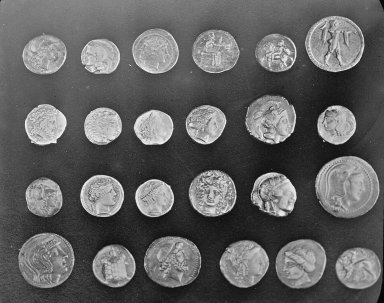

In [195]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, measure, filters, morphology
from scipy.ndimage import gaussian_filter

image = data.coins()
image

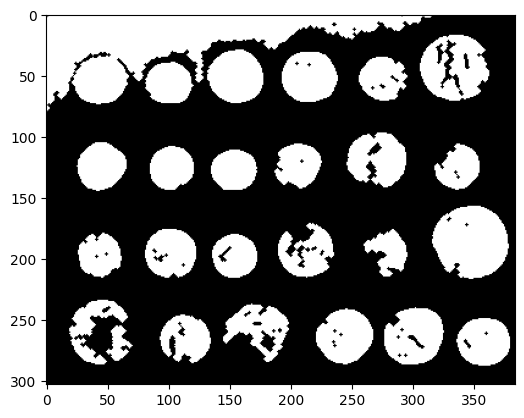

In [196]:
smoothed = gaussian_filter(image, sigma=3)
threshold = filters.threshold_otsu(smoothed)
binary = image > threshold
binary = morphology.binary_erosion(binary) #noise clean
binary = morphology.binary_opening(binary, morphology.disk(2))
binary = morphology.remove_small_objects(binary, min_size=300)
plt.imshow(binary, cmap='gray')


In [197]:
contours = measure.find_contours(binary, level=0.5) #select transition from black to white anything >0 works
contour = max(contours, key=len) #most significant one
contour.shape ,contour

((913, 2),
 array([[  0. , 316.5],
        [  0.5, 316. ],
        [  1. , 315.5],
        ...,
        [ 78.5,   1. ],
        [ 79. ,   0.5],
        [ 79.5,   0. ]]))

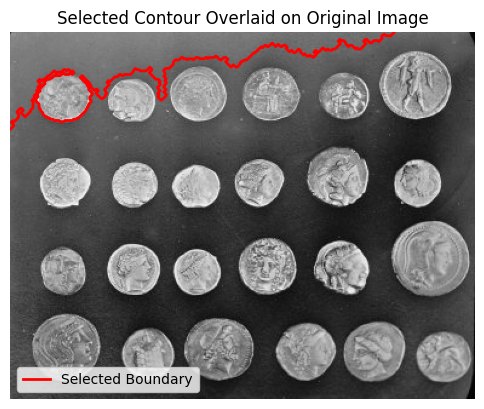

In [198]:
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.plot(contour[:, 1], contour[:, 0], color='red', linewidth=2, label='Selected Boundary')
plt.title("Selected Contour Overlaid on Original Image")
plt.axis('off')
plt.legend()
plt.show()

In [199]:

x, y = contour[:, 1], contour[:, 0]  # to Argand plane
z = x + 1j * y

Z = np.fft.fft(z)
N = len(Z)

In [200]:
def reconstruct(Z, M):
    Z_recon = np.zeros_like(Z)
    center = N // 2
    Z_recon[:M//2] = Z[:M//2]
    Z_recon[-(M//2):] = Z[-(M//2):]
    return np.fft.ifft(Z_recon)

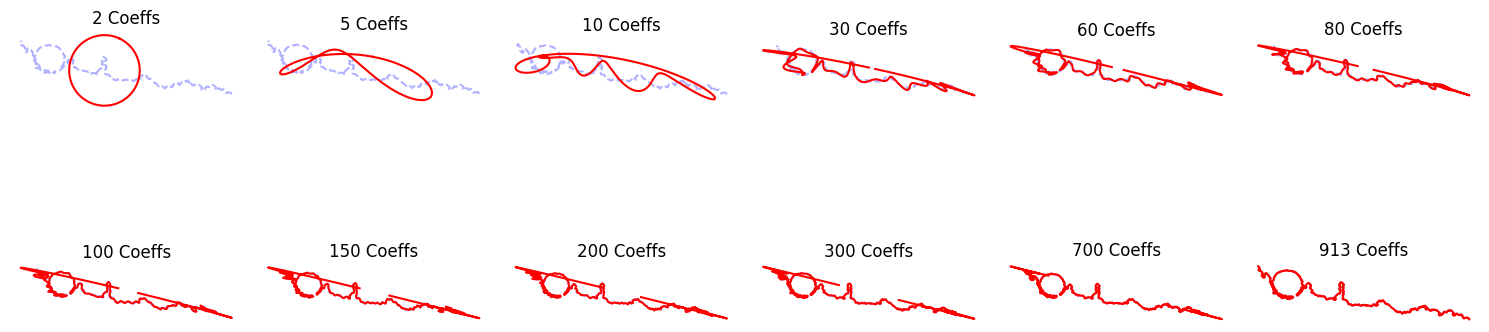

In [201]:
Ms = [2, 5, 10, 30, 60, 80, 100, 150, 200, 300,700,N]
fig, axes = plt.subplots(2, 6, figsize=(15, 6))

for i, M in enumerate(Ms):
    recon = reconstruct(Z, M)
    ax = axes[i // 6, i % 6]  # place subplot correctly
    ax.plot(z.real, z.imag, 'b--', label='Original', alpha=0.3)
    ax.plot(recon.real, recon.imag, 'r', label=f'{M} Coeffs')
    ax.set_aspect('equal')
    ax.set_title(f'{M} Coeffs')
    ax.axis('off')

plt.tight_layout()
plt.show()
#if the image was further noise free, we have could made it better